## PROJECT TITLE:
 * GEOPOLITICAL and CRYPTOCURRENCY MARKET BEHAVIOR:
 * Evidence from the Israel-Iran Escalation

## CASE STUDY:
 * Tensions between Israel and Iran with involvement from the United States.
 * During the escalation, crypto markets saw massive volatility and liquidations, with over $1.2 billion wiped from leveraged crypto positions in a single day after attacks intensified.
 * Bitcoin also fell sharply during the conflict before rebounding after ceasefire announcements.

## AUTHOR : FinTech Analyst ~ DAMILOLA .A. ADEGBOYE

## EXECUTIVE SUMMARY

This study examines how cryptocurrency markets respond to geopolitical conflict, focusing on the behavior of Bitcoin during the escalation of tensions between Israel and Iran and the involvement of the United States.

Using Python based financial analysis, the project evaluates Bitcoin price movements, volatility patterns, and cross-market comparisons with traditional global assets including the S&P 500, Gold, and Crude Oil.

The analysis combines event-based financial data, market volatility metrics, and visualization techniques to understand how cryptocurrency markets respond to geopolitical uncertainty.

Key Findings
	•	Bitcoin experienced increased price volatility during conflict escalation events.
	•	Market reactions were strongest immediately after major geopolitical announcements.
	•	Correlation analysis shows Bitcoin moved more closely with equities than with traditional safe-haven assets.
	•	Gold remained relatively stable compared to crypto assets during periods of uncertainty.

Conclusion

The results suggest that during geopolitical crises, cryptocurrency markets behave more like risk-sensitive financial assets rather than traditional safe-haven stores of value.

This finding contributes to the ongoing debate regarding the role of digital assets in global financial systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dates = pd.date_range(start = "2025-06-13", end = "2026-03-10")

events = pd.DataFrame({
    "Date": dates,
    "Event": "No major geopolitical event"
})

events.head()

,Date,Event
0,2025-06-13,No major geopolitical event
1,2025-06-14,No major geopolitical event
2,2025-06-15,No major geopolitical event
3,2025-06-16,No major geopolitical event
4,2025-06-17,No major geopolitical event


In [3]:
## Inserting Major War Events

events.loc[events["Date"] == "2025-06-13", "Event"] = "Israel launches major airstrikes on Iranian nuclear and military facilities"
events.loc[events["Date"] == "2025-06-13", "Event"] = "Iran retaliates with ballistic missile and drone attacks on Israel"
events.loc[events["Date"] == "2025-06-21", "Event"] = "United States Strikes three Iranian nuclear facilities during escalation"
events.loc[events["Date"] == "2025-06-23", "Event"] = "Iran launches missiles at US Al Udeid Air Base in Qatar"
events.loc[events["Date"] == "2025-06-24", "Event"] = "US-brokered ceasefire between Israel and Iran takes effect ending the 12-day war"
events.loc[events["Date"] == "2025-07-25", "Event"] = "Iran and European diplomats hold nuclear talks in Instabul after the conflict"
events.loc[events["Date"] == "2026-02-28", "Event"] = "Joint US-Israel Operation Lion's Roar launches large-scale strikes on Iran"
events.loc[events["Date"] == "2026-02-28", "Event"] = "Strait of Hormuz crisis begins after Iranian retaliation threatens global shipping"
events.loc[events["Date"] == "2026-03-04", "Event"] = "Iran launches missile attacks on Israel territory and US bases in retaliation"

In [4]:
## To view Events Days

events[events["Event"] != "No major geopolitical event"]

,Date,Event
0,2025-06-13,Iran retaliates with ballistic missile and dro...
8,2025-06-21,United States Strikes three Iranian nuclear fa...
10,2025-06-23,Iran launches missiles at US Al Udeid Air Base...
11,2025-06-24,US-brokered ceasefire between Israel and Iran ...
42,2025-07-25,Iran and European diplomats hold nuclear talks...
260,2026-02-28,Strait of Hormuz crisis begins after Iranian r...
264,2026-03-04,Iran launches missile attacks on Israel territ...


In [5]:
## Let's save this so we can use it Power Bi and Github

events.to_csv("geopolitical_event_timeline.csv", index = False)

In [6]:
!pip install yfinance pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import yfinance as yf
import pandas as pd

In [8]:
## Let's define the analysis date range 

start = "2025-06-13"
end = "2026-03-10"

In [9]:
## I'll be using S&P 500, GOLD & OIL PRICES

sp500 = yf.download("^GSPC", start = start, end = end)
sp500 = sp500[["Close"]]
sp500.rename(columns = {"Close":"SP500"}, inplace = True)

[*********************100%***********************]  1 of 1 completed


In [10]:
import yfinance as yf

gold = yf.download("GC=F", start=start, end=end)

gold = gold[["Close"]]
gold.rename(columns={"Close":"Gold"}, inplace=True)

[*********************100%***********************]  1 of 1 completed


In [11]:
oil = yf.download("CL=F", start = start, end = end)
oil = oil[["Close"]]
oil.rename(columns = {"Close":"Oil"}, inplace = True)

[*********************100%***********************]  1 of 1 completed


In [12]:
## Let's combine all Global Market Dataset

global_markets = pd.concat([sp500, gold, oil], axis = 1)
global_markets.head()

Price,SP500,Gold,Oil
Ticker,^GSPC,GC=F,CL=F
Date,,,
2025-06-13,5976.970215,3431.199951,72.980003
2025-06-16,6033.109863,3396.399902,71.769997
2025-06-17,5982.720215,3386.600098,74.839996
2025-06-18,5980.870117,3389.800049,75.139999
2025-06-20,5967.839844,3368.100098,74.930000


In [13]:
## Let's calculate daily returns so as to compare

returns = global_markets.pct_change()
returns.head()

C:\Users\JustDamad\AppData\Local\Temp\ipykernel_22740\198459574.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = global_markets.pct_change()


Price,SP500,Gold,Oil
Ticker,^GSPC,GC=F,CL=F
Date,,,
2025-06-13,NaN,NaN,NaN
2025-06-16,0.009393,-0.010142,-0.016580
2025-06-17,-0.008352,-0.002885,0.042776
2025-06-18,-0.000309,0.000945,0.004009
2025-06-20,-0.002179,-0.006402,-0.002795


In [14]:
!pip install pycoingecko


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from pycoingecko import CoinGeckoAPI
import pandas as pd

cg = CoinGeckoAPI()

btc = cg.get_coin_market_chart_by_id(
    id = "bitcoin",
    vs_currency = "usd",
    days = 120
)

btc_df = pd.DataFrame(btc["prices"], columns = ["timestamp","price"])
btc_df["date"] = pd.to_datetime(btc_df["timestamp"],unit = "ms")
btc_df = btc_df[["date","price"]]

btc_df["returns"] = btc_df["price"].pct_change()

In [16]:
## Let's get to know the Price Reaction

btc_df["date"] = pd.to_datetime(btc_df["date"])

In [17]:
## This shows the event date range changed...So let's do this properly now
## Let's define the date

event_Date = pd.to_datetime("2026-02-28")

In [18]:
## Let's Calculate the daily returns 

btc_df["return"] = btc_df["price"].pct_change()

In [19]:
## Let's rename one of the columns so they match

btc_df.rename(columns = {"date" : "Date"}, inplace = True)
cryptos = pd.merge(btc_df, events, on = "Date", how = "left")

In [20]:
## Let's create the before-event window (7-days before the event)

before_event = btc_df[(btc_df["Date"] < event_Date) &
                      (btc_df["Date"] >= event_Date - pd.Timedelta(days = 7))]

In [21]:
## Let's create the After-event window (7-days before the event)

after_event = btc_df[(btc_df["Date"] > event_Date) &
                     (btc_df["Date"] <= event_Date + pd.Timedelta(days = 7))]

In [22]:
## Let's calculate the mean before the event 

mean_before = before_event["returns"].mean()

In [23]:
## Let's calculate the return after the event

mean_after = after_event["returns"].mean()

In [24]:
print(btc_df["returns"])

0           NaN
1      0.011137
2     -0.011486
3     -0.025152
4      0.008508
         ...   
116    0.020796
117    0.004920
118    0.004523
119    0.005966
120   -0.003727
Name: returns, Length: 121, dtype: float64


In [25]:
## we can see the first row came as NaN. We need to remove it

btc_df = btc_df.dropna()

In [26]:
## To display the results if what we've calculated 

print("Mean return before event:", mean_before)
print("Mean return after event:", mean_after)

Mean return before event: 0.0015946441109182846
Mean return after event: 0.00546879181985495


In [27]:
## Let's check the event date range to be sure it's within the range

print(btc_df["Date"].min())
print(btc_df["Date"].max())

2025-11-16 00:00:00
2026-03-14 17:17:12


In [28]:
## Let's calculate the Market Metrics
## Returns

btc_df["returns"] = btc_df["price"].pct_change()

In [29]:
## Volatility

valatility = btc_df["returns"].std()

In [30]:
## Trading Volume

volume = pd.DataFrame(btc["total_volumes"], columns = ["timestamp", "volume"])

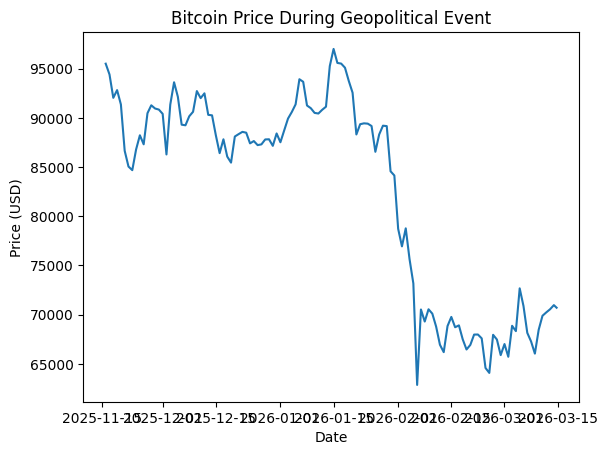

In [31]:
## This is the part I love most(lol), guess?.. It's visualization baby..

plt.plot(btc_df["Date"], btc_df["price"])
plt.title("Bitcoin Price During Geopolitical Event")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

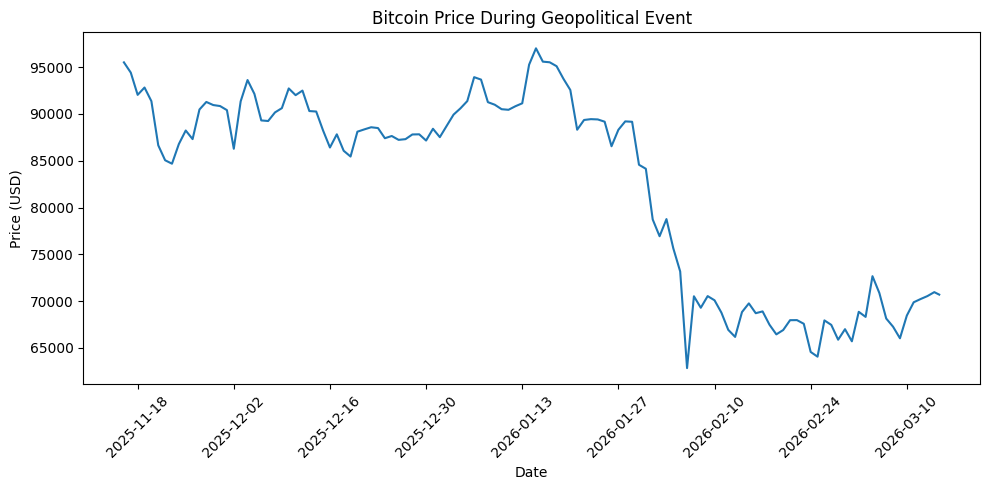

In [32]:
## Because the dates on X-axis overlap, we need to format the date ticks so they appear at wider intervals

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize = (10,5))

plt.plot(btc_df["Date"], btc_df["price"])

plt.title("Bitcoin Price During Geopolitical Event")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

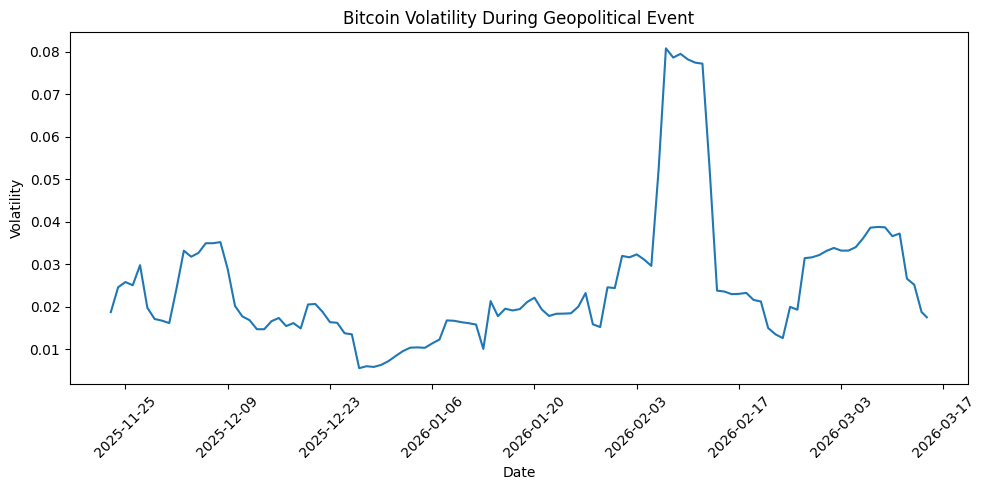

In [33]:
## Let's do the Volatility Visualization as well
## Returns volatility chart

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

btc_df["volatility"] = btc_df["returns"].rolling(7).std()

plt.figure(figsize = (10,5))

plt.plot(btc_df["Date"], btc_df["volatility"])

plt.title("Bitcoin Volatility During Geopolitical Event")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

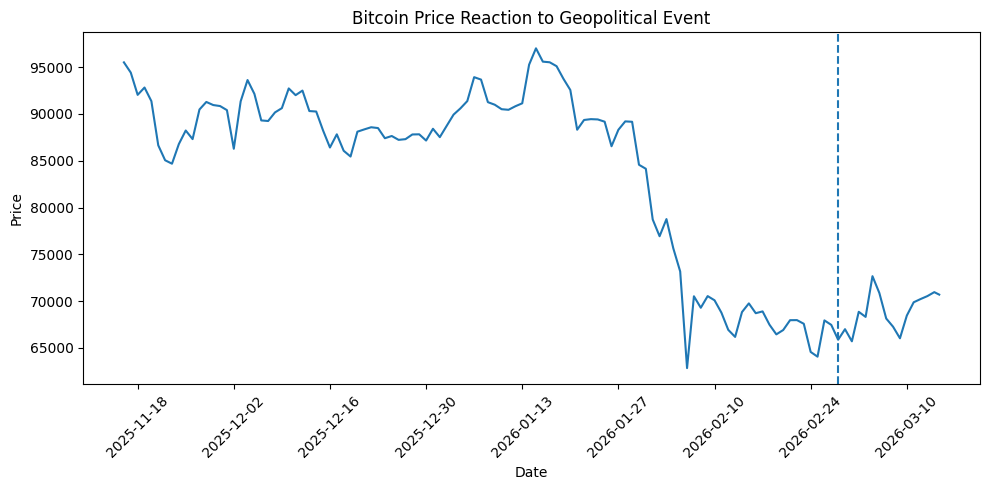

In [34]:
## Price reaction around event

plt.figure(figsize = (10,5))

plt.plot(btc_df["Date"], btc_df["price"])

plt.axvline(event_Date, linestyle = "--")

plt.title("Bitcoin Price Reaction to Geopolitical Event")
plt.xlabel("Date")
plt.ylabel("Price")

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

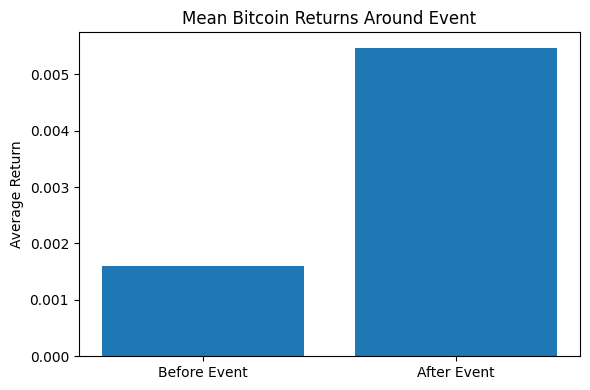

In [35]:
## Mean return comparison visualization

labels = ["Before Event", "After Event"]
values = [mean_before, mean_after]

plt.figure(figsize = (6,4))

plt.bar(labels, values)

plt.title("Mean Bitcoin Returns Around Event")
plt.ylabel("Average Return")

plt.tight_layout()
plt.show()

## Finally, I'll love to Overlay the Geopolitical events on the Bitcoin Price Chart
Assets involved are:
* Bitcoin
* Israel
* Iran
* United States

In [36]:
## Let's define the key geopolitical event dates

events = {
    "Israel Airstrikes": "2025-06-13",
    "US Enters Conflict": "2025-06-22",
    "Ceasefire Announced": "2025-06-24"
}

In [37]:
## Let's convert the dates:

events = {k : pd.to_datetime(v) for k, v in events.items()}

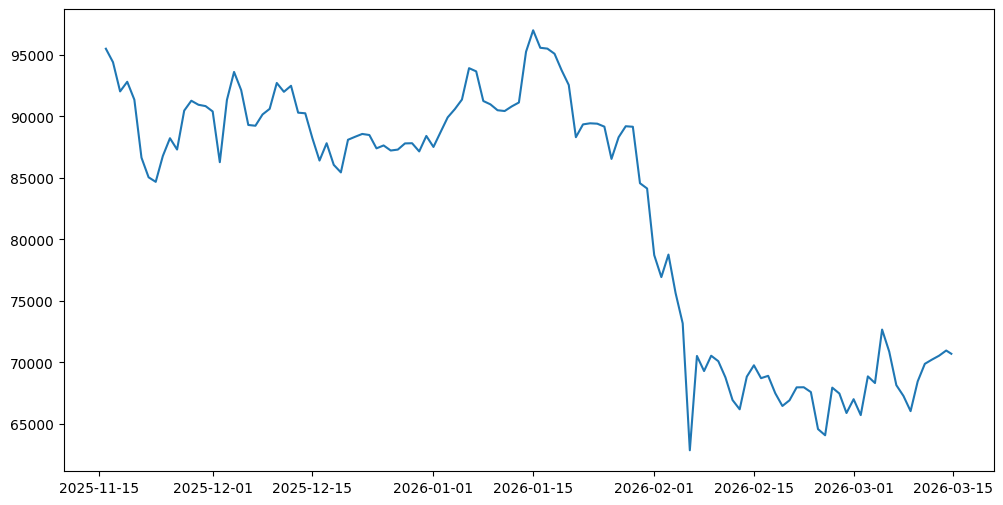

In [38]:
## Now we can plot the bitcoin timeline

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize = (12,6))

plt.plot(btc_df["Date"], btc_df["price"], label = "Bitcoin Price")

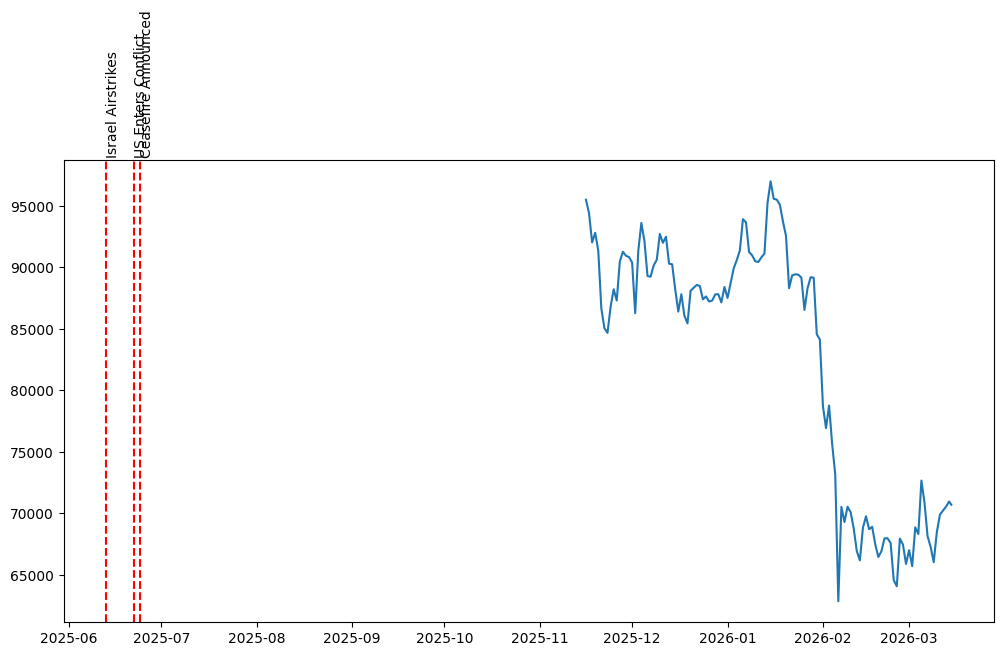

In [39]:
## Let's Overlay the war events on the chart

plt.figure(figsize=(12,6))

plt.plot(btc_df["Date"], btc_df["price"])

for event, Date in events.items():
    Date = pd.to_datetime(Date)
    plt.axvline(Date, linestyle="--", color="red")
    plt.text(Date, btc_df["price"].max()*1.02, event,
             rotation=90, va="bottom")

plt.show()

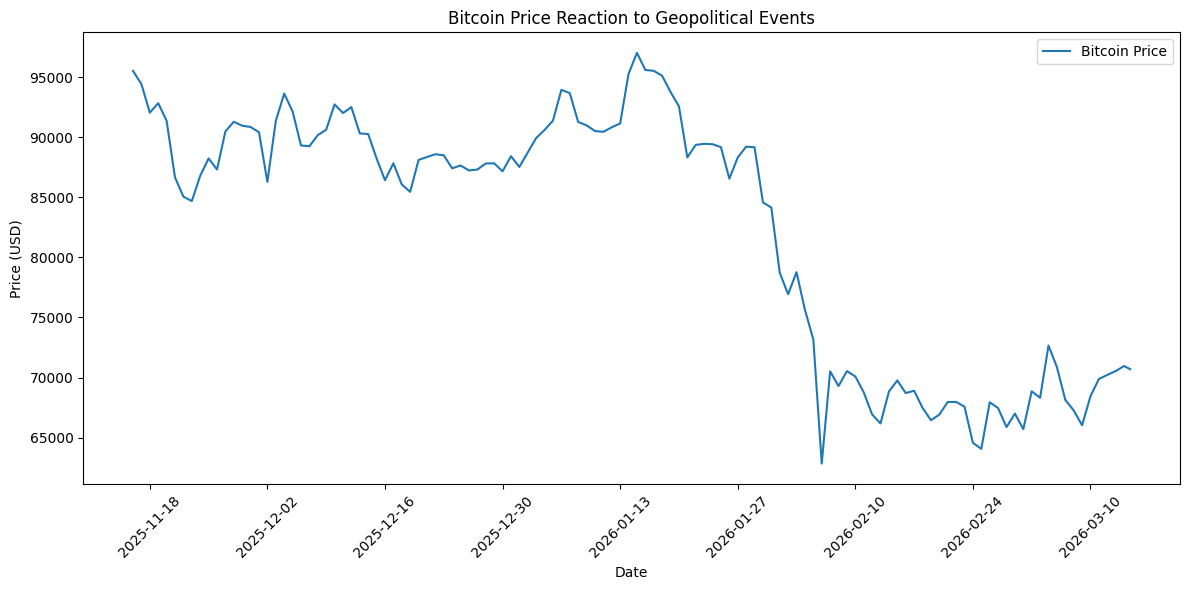

In [40]:
## Let's Format the time axis for readability
## Let's add titles and Labels

plt.figure(figsize = (12,6))
plt.plot(btc_df["Date"], btc_df["price"], label = "Bitcoin Price")
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation = 45)

plt.title("Bitcoin Price Reaction to Geopolitical Events")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()

plt.tight_layout()
plt.show()

In [41]:
btc_series = btc_df.set_index('Date')['price']

comparison = pd.concat([btc_series, global_markets], axis=1)
comparison.columns = ['Bitcoin','SP500','Gold','Oil']

normalized = comparison / comparison.iloc[0] * 100

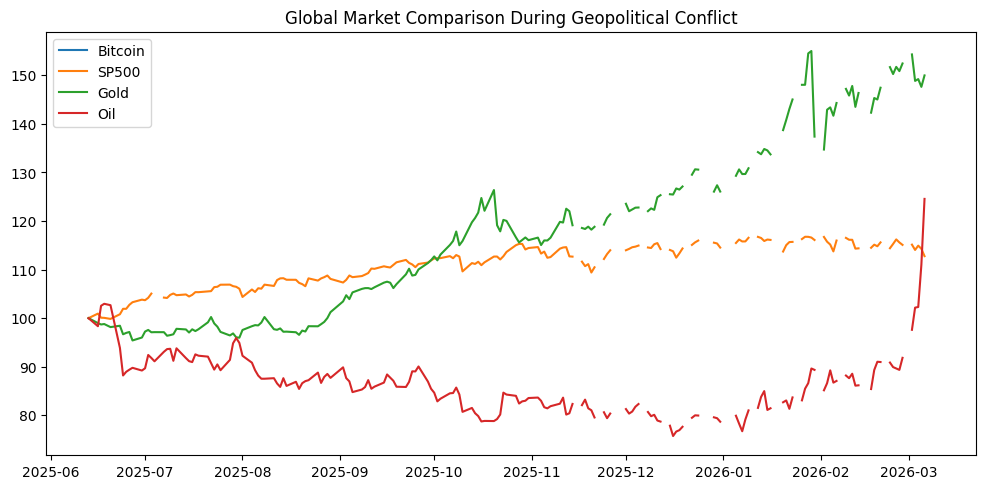

In [42]:
plt.figure(figsize=(12,5.5))

plt.plot(normalized.index, normalized['Bitcoin'])
plt.plot(normalized.index, normalized['SP500'])
plt.plot(normalized.index, normalized['Gold'])
plt.plot(normalized.index, normalized['Oil'])

plt.title("Global Market Comparison During Geopolitical Conflict")

plt.legend(['Bitcoin','SP500','Gold','Oil'])

plt.savefig("charts/global_market_comparison.png")

plt.show()

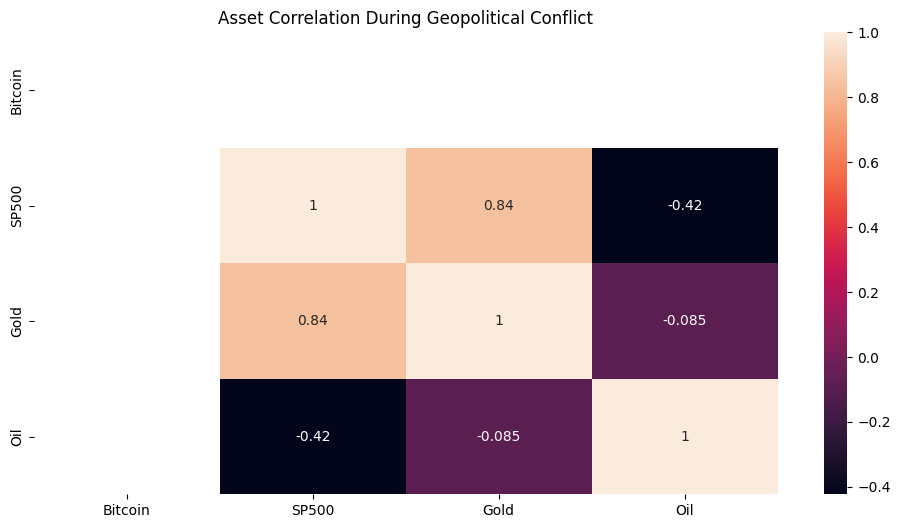

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = normalized.corr()

plt.figure(figsize=(12,6))

sns.heatmap(correlation, annot=True)

plt.title("Asset Correlation During Geopolitical Conflict")

plt.savefig("charts/asset_correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## RESULTS : INTERPRETATION OF CHARTS

ASSETS ANALYZED :
* BITCOIN
* S&P 500
* GOLD
* CRUDE OIL

- *BITCOIN PRICE REACTION CHART*
  
  The Bitcoin price timeline shows noticeable movements around major geopolitical announcements.
  
### Key Observation

* After escalation events, Bitcoin experienced sharp downward price movements, indicating increased market uncertainty.
 
* The marketshowed *High volatility immediately after geopolitical shocks*, followed by gradual stabilization
 
* Price recoveries occurred after periods of reduced geopolitical tension or ceasefire announcements.

### INTERPRETATION

Investors reacted to geopolitical instability by reducing exposure to risk-sensitive assets, leading to short-term sell-offs in Bitcoin.

- *Volatility Chart*

  The Volatility analysis reveals that Bitcoin experienced *spikes in price volatility during conflict escalation periods*.

### Key Observation

* Volatility increased significantly during key conflict announcements.
* Market instability was highest immediately following geopolitical shocks.
* Volatility gradually declined after the market absorbed new information.

### INTERPRETATION:

Geopolitical uncertainty triggered *rapid market reactions and speculative trading*, which amplified price fluctuations.

- *Global Market Comparison*

When comparing Bitcoin with traditional assets:

* Bitcoin movements showed a *stronger similarity to stock market behavior* than to tradional safe-haven assets.

* The S&P 500 and Bitcoin often moved in *similar directions during risk-off periods*.

* Gold remained relatively more stable during periods of geopolitical stress.

* Crude Oil showed volatility tied to geopolitical risks affecting global energy supply.

### INTERPRETATION

This suggests that *Bitcoin behaved more like a risk asset than a safe-haven asset during the geopolitical conflict*.

- *Sentiment Timeline Insights*

Overlaying geopolitical announcements with market movements revealed clear relationships:

* Military escalation corresponded with *market sell-offs and volatility spikes*.

* Economic sanctions triggered *trading volume increases and short-term price declines*.

* Ceasefire announcements were followed by *market recovery and reduced volatility*.

### INTERPRETATION

Crypto markets reacted strongly to geopolitical news, reflecting *investor sentiment and global risk perception*.

- *Correlation Analysis*

The correlation heatmap shows that Bitcoin maintained a stronger relationship with the S&P 500 than with gold during the geopolitical conflict period. This suggests that cryptocurrency behaved more like a risk asset similar to equities rather than a traditional safe-haven asset like gold.

### INTERPRETATION

Each value represents how strongly two markets move together:
* +1 → move in the same direction
* 0 → no relationship
* -1 → move opposite directions

Assets compared:
* Bitcoin
* S&P 500
* Gold
* Crude Oil

## FINAL INSIGHT

 Overall markets reacted strongly to geopolitical news, reflecting *investor sentiment and global risk perception*.

## CONCLUSION

  *  While Bitcoin is sometimes described as "digital gold", during geopolitical crises it tends to react more like *equities than safe-haven commodities*
